# Preprocessing

## Importing Modules

In [1]:
pip install dtreeviz

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.svm import SVR
import seaborn as sns
from imblearn.under_sampling import RandomUnderSampler

## Importing Dataset

In [3]:
# The file path with forward slashes is recommended for stability
file_path = "C:/Users/Anjali Singh/Downloads/Employee_Attrition_Prediction-main/WA_Fn-UseC_-HR-Employee-Attrition.csv"

# Load the dataset using the pyarrow engine for faster performance
df = pd.read_csv(file_path, engine='pyarrow')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Missing Values

In [5]:
df.isna().any().any()

np.False_

## Encoding String Values

In [6]:
#Columns with string values
categorical_column = ['Attrition', 'BusinessTravel', 'Department', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime','EducationField']
encoder=LabelEncoder()
df[categorical_column]=df[categorical_column].apply(encoder.fit_transform)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   int64 
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   int64 
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   int64 
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   int64 
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## Separating Features from Output

In [8]:
Y=df['Attrition']
X=df.drop(['EmployeeCount','Attrition','EmployeeNumber','Over18','StandardHours'],axis=1)

In [9]:
rus = RandomUnderSampler(random_state=42,replacement=True)
X_, Y = rus.fit_resample(X,Y)
X = pd.DataFrame(X_,columns=X.columns)

## Train-Test-Split

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=4)

# Decision Tree

### Import Modules

In [12]:
import graphviz
from subprocess import check_call
from IPython.display import Image
#from dtreeviz.trees import dtreeviz
from dtreeviz import dtreeviz
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text, plot_tree, _tree
from sklearn.metrics import make_scorer, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, log_loss
import matplotlib.font_manager

## Decision Tree Classifier

Function to Visualize Decision Tree Model

In [20]:
import warnings
from subprocess import check_call
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text, plot_tree
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt

def decision_tree_maker(X_train, y_train, X_test, y_test, my_depth=5):
    """
    Trains and visualizes a decision tree model.
    """
    # Train the model
    dt = DecisionTreeClassifier(random_state=0, max_depth=my_depth, criterion='entropy')
    dt.fit(X_train, y_train)

    # Test the model
    y_pred = dt.predict(X_test)

    # Metric evaluation
    dt_accuracy = accuracy_score(y_test, y_pred)
    print('Accuracy = ', dt_accuracy)
    dt_f1 = f1_score(y_test, y_pred)
    print('F1 Score = ', dt_f1)
    dt_precision = precision_score(y_test, y_pred)
    print('Precision = ', dt_precision)
    dt_recall = recall_score(y_test, y_pred)
    print('Recall = ', dt_recall)
    dt_confusion_matrix = confusion_matrix(y_test, y_pred)
    print('Confusion Matrix:\n', dt_confusion_matrix)

    features = ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField',
                'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
                'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
                'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
                'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
                'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
    
    # Text representation of decision tree
    text_representation = export_text(dt, feature_names=features)
    print('------------ Text Representation of Decision Tree ----------')
    print(text_representation)

    warnings.filterwarnings('ignore')

    # graphical representation of decision tree using scikit-learn's plot_tree
    # This is a more stable way to visualize the tree
    plt.figure(figsize=(20,10))
    plot_tree(dt, filled=True, rounded=True, feature_names=features, class_names=['No', 'Yes'])
    plt.show()

    return dt

### Train and Test Decision Tree Model

Accuracy =  0.6526315789473685
F1 Score =  0.5714285714285714
Precision =  0.6111111111111112
Recall =  0.5365853658536586
Confusion Matrix:
 [[40 14]
 [19 22]]
------------ Text Representation of Decision Tree ----------
|--- OverTime <= 0.50
|   |--- StockOptionLevel <= 0.50
|   |   |--- JobRole <= 6.50
|   |   |   |--- JobSatisfaction <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- JobSatisfaction >  1.50
|   |   |   |   |--- class: 0
|   |   |--- JobRole >  6.50
|   |   |   |--- YearsWithCurrManager <= 4.00
|   |   |   |   |--- class: 1
|   |   |   |--- YearsWithCurrManager >  4.00
|   |   |   |   |--- class: 0
|   |--- StockOptionLevel >  0.50
|   |   |--- JobInvolvement <= 3.50
|   |   |   |--- EnvironmentSatisfaction <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- EnvironmentSatisfaction >  1.50
|   |   |   |   |--- class: 0
|   |   |--- JobInvolvement >  3.50
|   |   |   |--- class: 0
|--- OverTime >  0.50
|   |--- MonthlyIncome <= 2780.00
|   |   |--- EducationFi

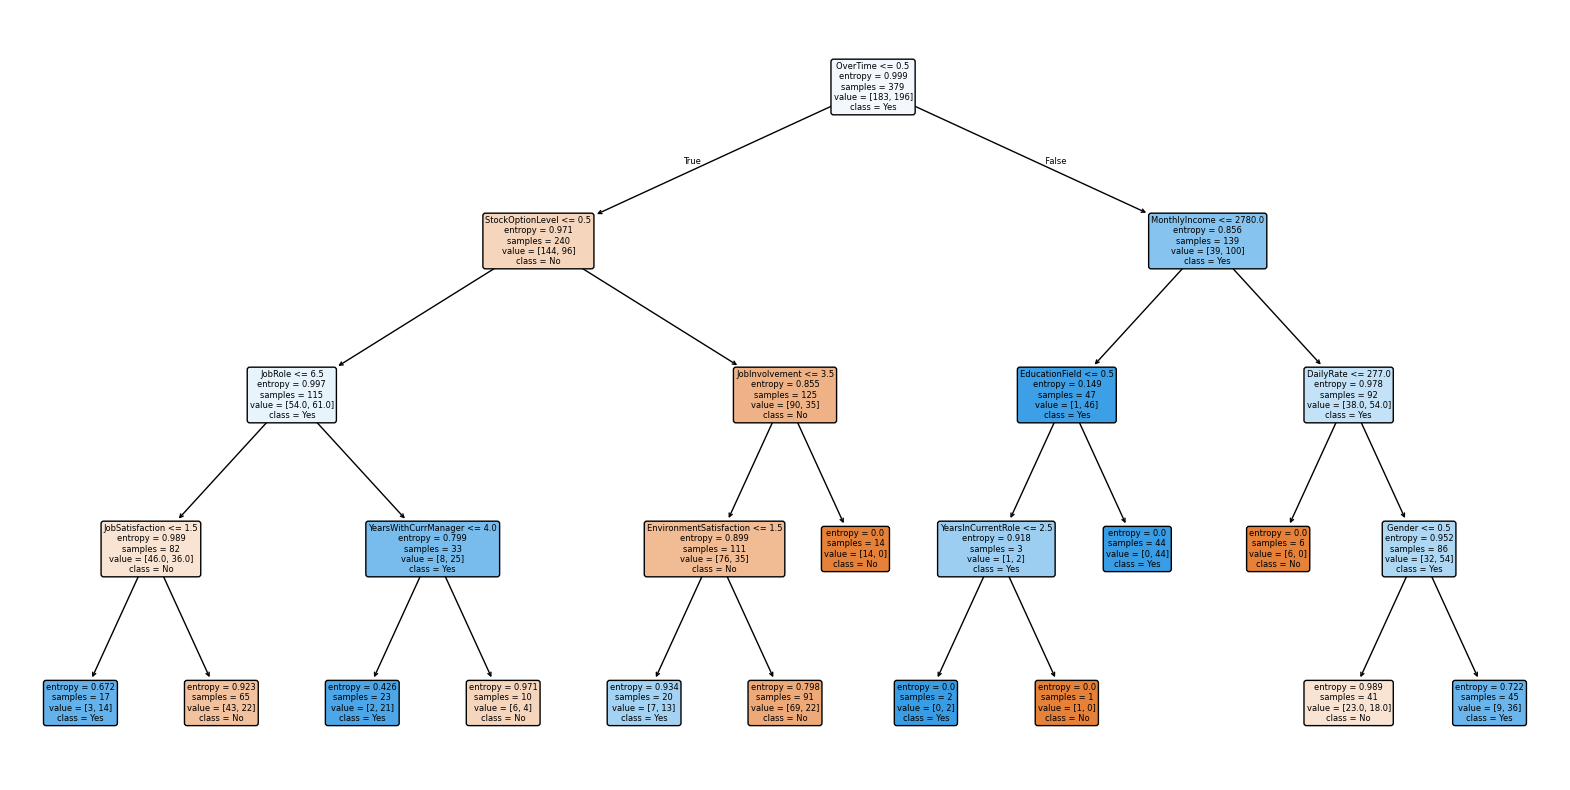

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
decision_tree_maker(X_train, y_train, X_test, y_test, 4)

Visualize Decision Tree Model

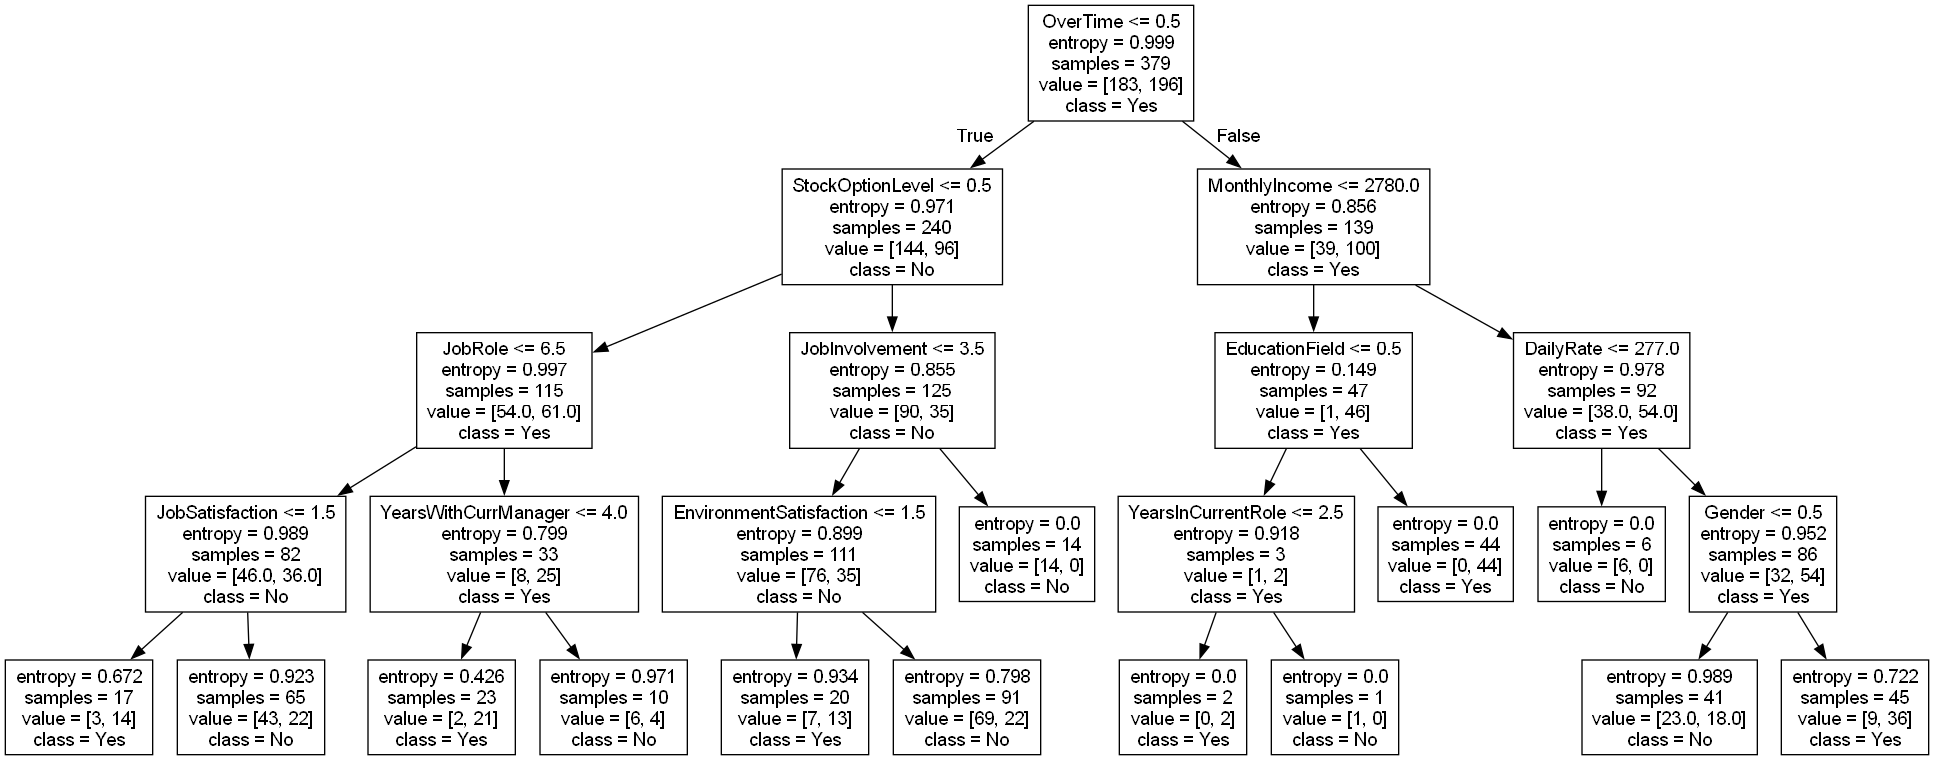

In [22]:
 # graphical represenation of decision tree, view file 'decision_tree.png'
 Image('decision_tree.png')

Function for Feature Importance for Decision Trees

In [23]:
def get_feature_importance(dt, X_train):
  # feature importance
  # The importance of a feature is computed as the (normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance.
  for importance, name in sorted(zip(dt.feature_importances_, X_train.columns), reverse=True):
    print(name, importance)

  # plot
  plt.xticks(rotation='vertical')
  plt.bar(X_train.columns, dt.feature_importances_, align='edge', width=0.3)
  plt.xlabel("Features")
  plt.ylabel("Importance")
  plt.title("Feature Importance for the Decision tree")
  plt.show()

## Hyperparameter Tuning using GridSearch CV 

Analyzing Accuracy with Depth of Decision Tree

[]

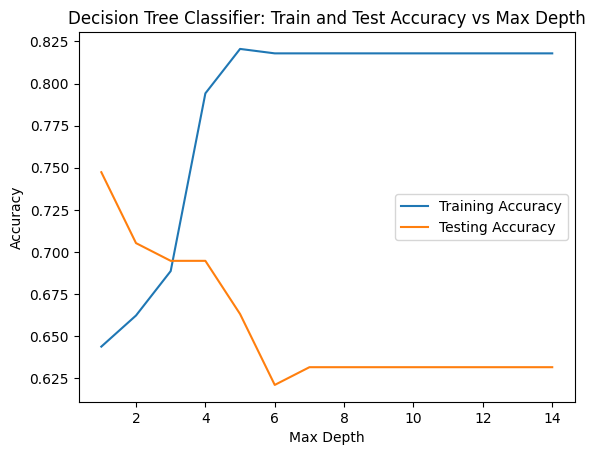

In [24]:
dt_train_accuracy = []
dt_test_accuracy = []

# do GridSearch CV over different values
for i in np.arange(1, 15):
  param_grid = {'criterion':['entropy','gini'],'max_depth': [i],'max_leaf_nodes':[5, 10, 20, 50, 100],'random_state':[0]}
  dt = GridSearchCV(DecisionTreeClassifier(random_state=0), param_grid, cv=5)
  dt.fit(X_train,y_train)
  y_train_pred = dt.predict(X_train)
  y_pred = dt.predict(X_test)
  s = accuracy_score(y_train, y_train_pred)
  dt_train_accuracy.append(s)
  dt_test_accuracy.append(accuracy_score(y_test, y_pred))

# plot graph
plt.title("Decision Tree Classifier: Train and Test Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.plot(np.arange(1,15), dt_train_accuracy, label="Training Accuracy")
plt.plot(np.arange(1,15), dt_test_accuracy, label="Testing Accuracy")
plt.legend()
plt.plot()

In [25]:
# print values at max depth = 4
print('Train Accuracy at max depth = 4 : ', dt_train_accuracy[3])
print('Train Accuracy at max depth = 4 : ', dt_test_accuracy[3])

Train Accuracy at max depth = 4 :  0.7941952506596306
Train Accuracy at max depth = 4 :  0.6947368421052632


Function for Grid Search CV

In [26]:
# performing GridSearchCV on data to get best model hyperparameters
def gcv(X_train, Y_train, X_test, Y_test):

  # make scorer
  scoring = make_scorer(accuracy_score)

  # define parameters
  max_depth = [int(x) for x in np.linspace(2, 15, num=10)] 
  # max_depth.append(None)

  # perform GridSearchCV with given parameters
  g_cv = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0),
                param_grid={'criterion': ['gini', 'entropy'],
                            'max_depth': max_depth,
                            'max_features': ['auto', 'log2', 'sqrt', 0.33334],
                            'min_samples_leaf': [1, 2, 5, 10, 15, 20],
                            'min_samples_split': range(2, 10),
                            'max_leaf_nodes': [5, 10, 20, 50, 100],
                            'random_state': [0]},
                scoring=scoring, cv=5, refit=True)

  g_cv.fit(X_train, Y_train)

  # get best parameter values
  print(g_cv.best_params_)

  # train new model with best parameters
  dt_classifier = DecisionTreeClassifier(**g_cv.best_params_).fit(X_train, Y_train)
  Y_pred = dt_classifier.predict(X_test)
  dt_accuracy = accuracy_score(Y_test, Y_pred)
  print('Accuracy = ', dt_accuracy)
  dt_f1 = f1_score(Y_test, Y_pred)
  print('F1 Score = ', dt_f1)
  dt_precision = precision_score(Y_test, Y_pred)
  print('Precision = ', dt_precision)
  dt_recall = recall_score(Y_test, Y_pred)
  print('Recall = ', dt_recall)
  return dt_classifier, g_cv.best_params_, dt_accuracy

Run Grid Search CV

In [27]:
dt_classifier, best_params_raw, accuracy_cv = gcv(X_train, y_train, X_test, y_test)

{'criterion': 'entropy', 'max_depth': 9, 'max_features': 0.33334, 'max_leaf_nodes': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'random_state': 0}
Accuracy =  0.6947368421052632
F1 Score =  0.6506024096385542
Precision =  0.6428571428571429
Recall =  0.6585365853658537


### Visualizing Decision Tree Model 

Decision Tree Model with Best Parameters

Accuracy =  0.6947368421052632
F1 Score =  0.6506024096385542
Precision =  0.6428571428571429
Recall =  0.6585365853658537


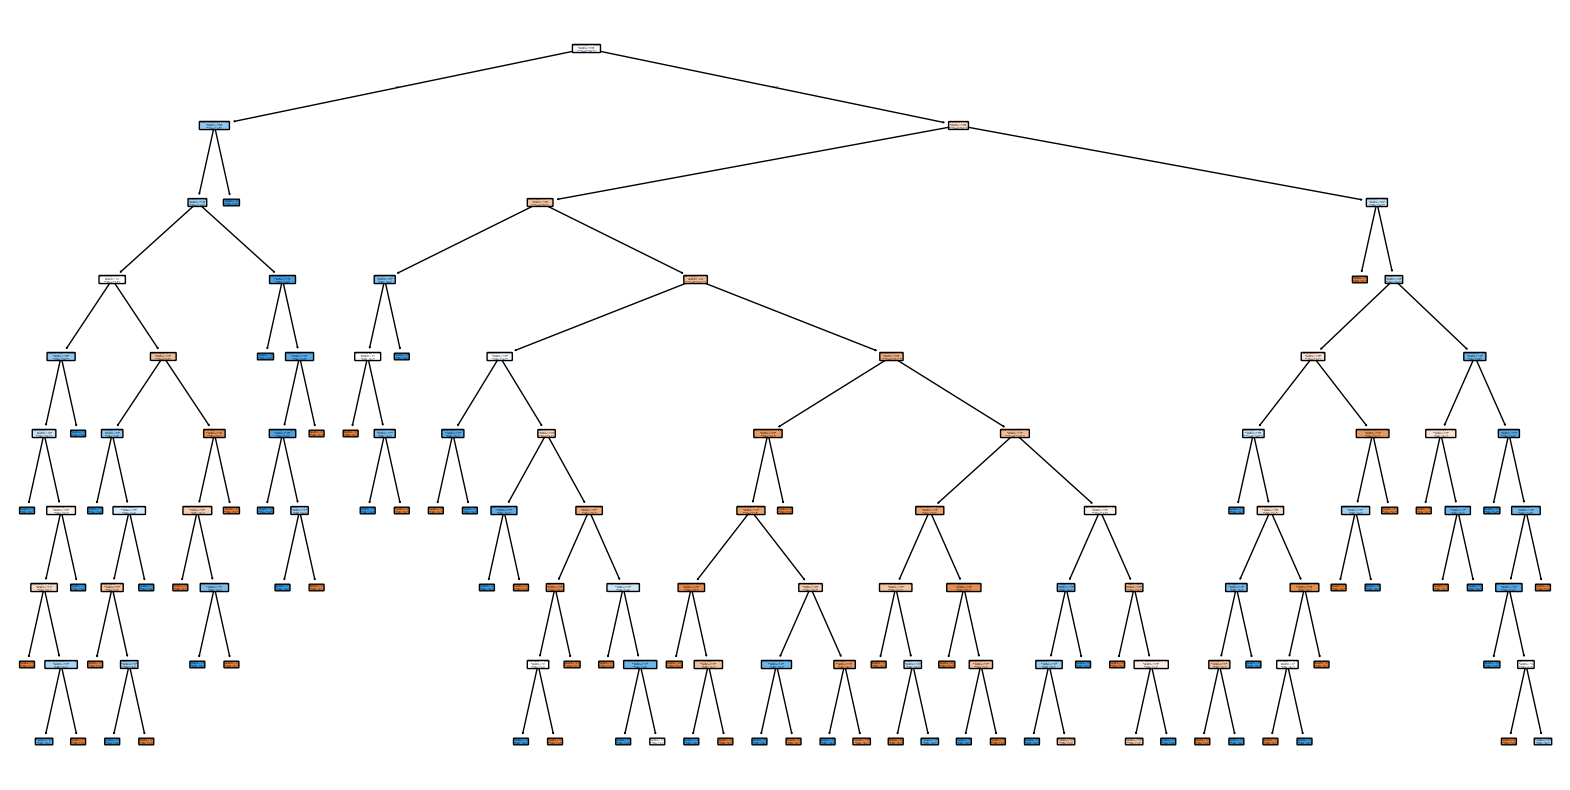

In [30]:
import warnings
# train new model with best parameters
dt_classifier = DecisionTreeClassifier(**best_params_raw).fit(X_train, y_train)
Y_pred = dt_classifier.predict(X_test)
dt_accuracy = accuracy_score(y_test, Y_pred)
print('Accuracy = ', dt_accuracy)
dt_f1 = f1_score(y_test, Y_pred)
print('F1 Score = ', dt_f1)
dt_precision = precision_score(y_test, Y_pred)
print('Precision = ', dt_precision)
dt_recall = recall_score(y_test, Y_pred)
print('Recall = ', dt_recall)
features = ['Age', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',  'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',  'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears',  'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
classes = ['No', 'Yes']
#np.warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning)
warnings.filterwarnings('ignore')
# graphical representation of decision tree using scikit-learn's plot_tree
# This is a more stable way to visualize the tree
plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, filled=True, rounded=True, feature_names=features, class_names=classes)
plt.show()

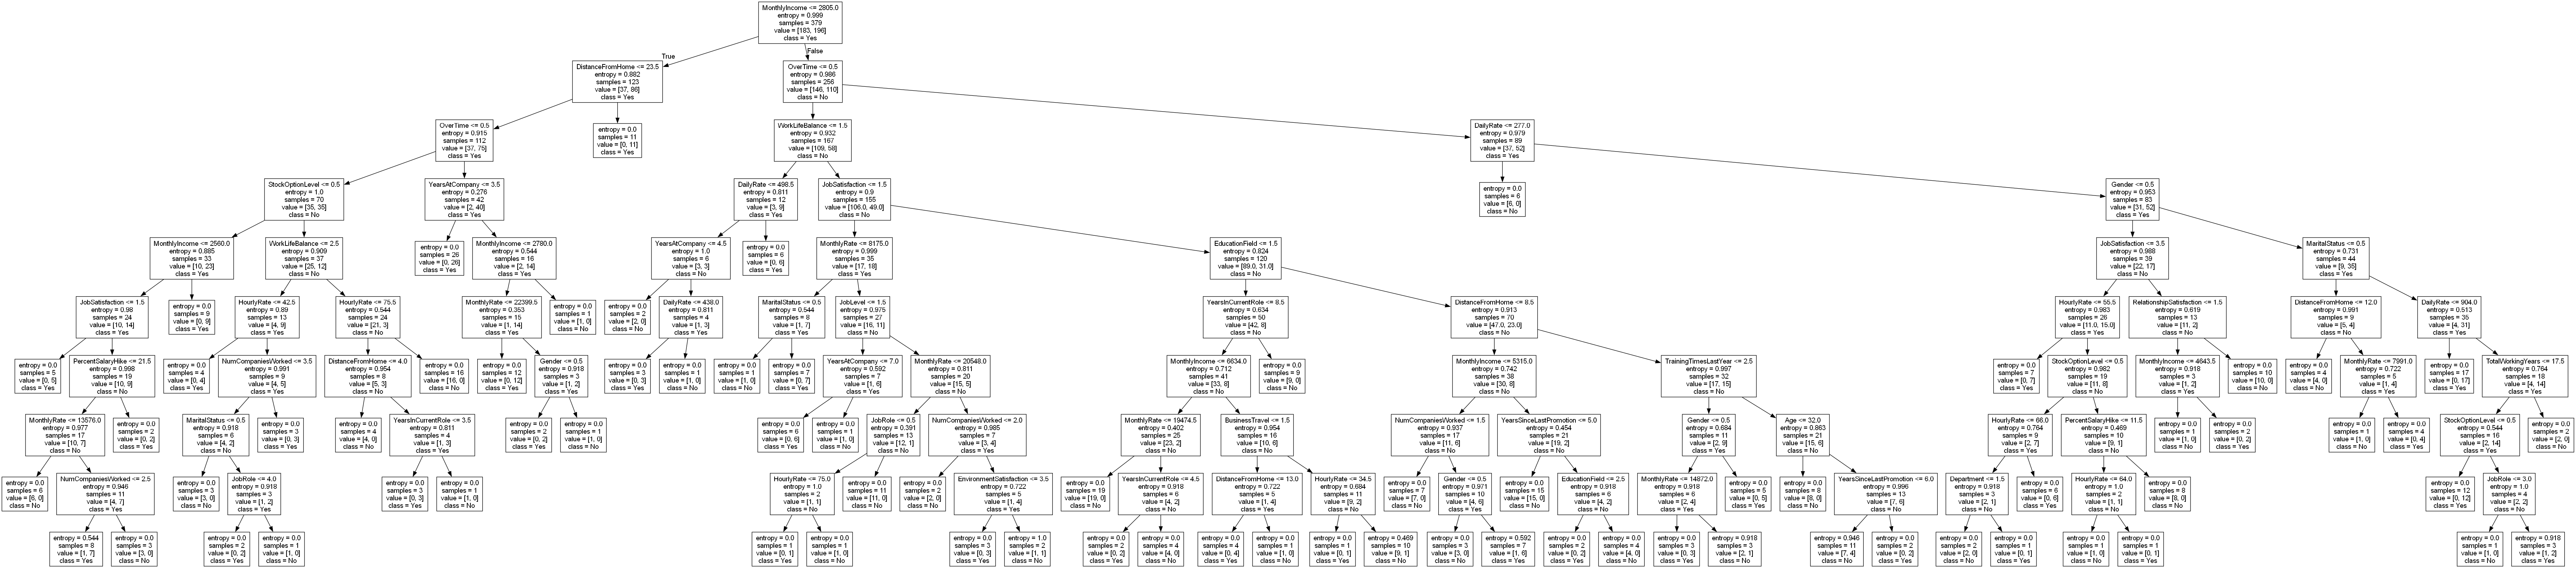

In [31]:
Image('decision_tree_best.png')

### Feature Importance

MonthlyIncome 0.10441245463420132
OverTime 0.08773985235080312
MonthlyRate 0.08117135326629837
HourlyRate 0.07457621342277701
DistanceFromHome 0.06656227670805509
DailyRate 0.055272361670138825
NumCompaniesWorked 0.054560454156181354
StockOptionLevel 0.054514527132832426
Gender 0.05398827073438642
WorkLifeBalance 0.04413652180531118
JobSatisfaction 0.04349396515092365
MaritalStatus 0.0356736375007534
YearsInCurrentRole 0.03244013566195906
YearsAtCompany 0.028193805542214193
EducationField 0.02519835682096389
JobRole 0.02038679658243795
YearsSinceLastPromotion 0.01887435192318945
TrainingTimesLastYear 0.018009404660172965
JobLevel 0.017149545040366553
RelationshipSatisfaction 0.015239624421144913
Age 0.014905876958942032
TotalWorkingYears 0.014553661923719012
PercentSalaryHike 0.014488123638360237
BusinessTravel 0.011901745324683704
Department 0.007925770934656476
EnvironmentSatisfaction 0.004630912034527402
YearsWithCurrManager 0.0
PerformanceRating 0.0
JobInvolvement 0.0
Education 0.0

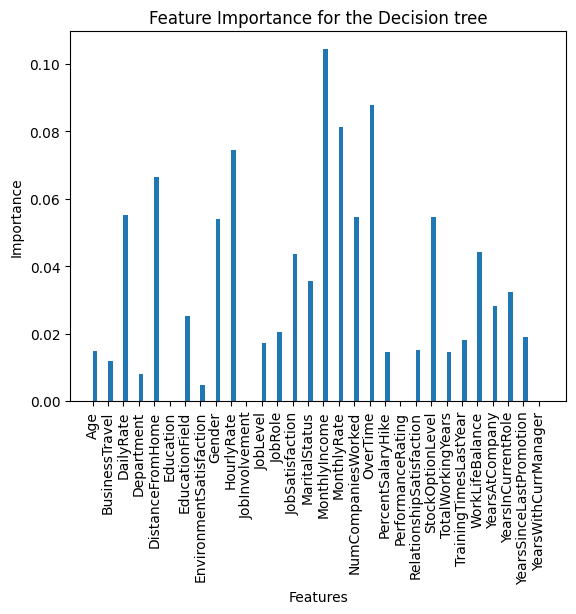

In [32]:
get_feature_importance(dt_classifier, X_train)

## K Fold Cross Validation

In [33]:
def cross_validation(model, X, y, my_cv = 5):
  scores = cross_validate(model, X, y, cv=my_cv, scoring=('accuracy','precision','recall','f1'))
  print(scores)
  print("Accuracy: ", np.mean(scores['test_accuracy']))
  print("Precision: ", np.mean(scores['test_precision']))
  print("Recall: ", np.mean(scores['test_recall']))
  print("F1 Score: ", np.mean(scores['test_f1']))

### Performing K Fold Cross Validation with above Hyperparameters

In [34]:
cross_validation(DecisionTreeClassifier(**best_params_raw), X, Y, 5)

{'fit_time': array([0.01055408, 0.00709653, 0.00686955, 0.00623775, 0.00562072]), 'score_time': array([0.0160563 , 0.015347  , 0.02010703, 0.01213074, 0.01043487]), 'test_accuracy': array([0.63157895, 0.70526316, 0.66315789, 0.63157895, 0.69148936]), 'test_precision': array([0.64285714, 0.75675676, 0.7       , 0.63829787, 0.6875    ]), 'test_recall': array([0.57446809, 0.59574468, 0.58333333, 0.625     , 0.70212766]), 'test_f1': array([0.60674157, 0.66666667, 0.63636364, 0.63157895, 0.69473684])}
Accuracy:  0.6646136618141097
Precision:  0.685082354390865
Recall:  0.6161347517730495
F1 Score:  0.647217533107539
